<a href="https://colab.research.google.com/github/Gabnyb/Alzheimer-s-Analytics/blob/main/INFO381A_LR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub as kh
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, accuracy_score, f1_score

c:\Users\jonas\Projects\uib\381\Alzheimer-s-Analytics\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Load dataset

In [2]:
path = kh.dataset_download("rabieelkharoua/alzheimers-disease-dataset")
print("Path to dataset files:", path)

files = os.listdir(path)
print("Files in directory:", files)

csv_file = [f for f in files if f.endswith('.csv')][0]
csv_path = os.path.join(path, csv_file)


df = pd.read_csv(csv_path)
print("Shape:", df.shape)
df.head()

100%|██████████| 268k/268k [00:00<00:00, 588kB/s]

Extracting files...
Path to dataset files: C:\Users\jonas\.cache\kagglehub\datasets\rabieelkharoua\alzheimers-disease-dataset\versions\1
Files in directory: ['alzheimers_disease_data.csv']
Shape: (2149, 35)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


Basic overview

In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64  
 14  Dep

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Check for missing values

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0]
missing.sort_values(ascending=False)

Series([], dtype: int64)

Class distribution

In [5]:
df['Diagnosis'].value_counts()
df['Diagnosis'].value_counts(normalize=True)

Diagnosis
0    0.646347
1    0.353653
Name: proportion, dtype: float64

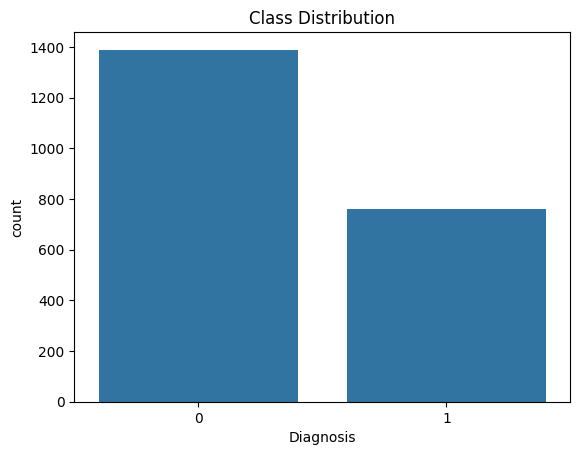

In [6]:
sns.countplot(x='Diagnosis', data=df)
plt.title("Class Distribution")
plt.show()

Drop irrelevant columns

In [7]:
df = df.drop(columns=['PatientID', 'DoctorInCharge'], errors='ignore')

Separate feature types

In [9]:
binary_cols = [
    'Gender', 'Smoking', 'FamilyHistoryAlzheimers',
    'CardiovascularDisease', 'Diabetes', 'Depression',
    'HeadInjury', 'Hypertension',
    'MemoryComplaints', 'BehavioralProblems',
    'Confusion', 'Disorientation',
    'PersonalityChanges', 'DifficultyCompletingTasks',
    'Forgetfulness'
]

categorical_cols = ['Ethnicity', 'EducationLevel']

target_col = 'Diagnosis'

numeric_cols = [col for col in df.columns
                if col not in binary_cols + categorical_cols + [target_col]]

Verify

In [10]:
print("Numeric:", numeric_cols)
print("Binary:", binary_cols)
print("Categorical:", categorical_cols)

Numeric: ['Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL']
Binary: ['Gender', 'Smoking', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'MemoryComplaints', 'BehavioralProblems', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness']
Categorical: ['Ethnicity', 'EducationLevel']


Correlation Matrix

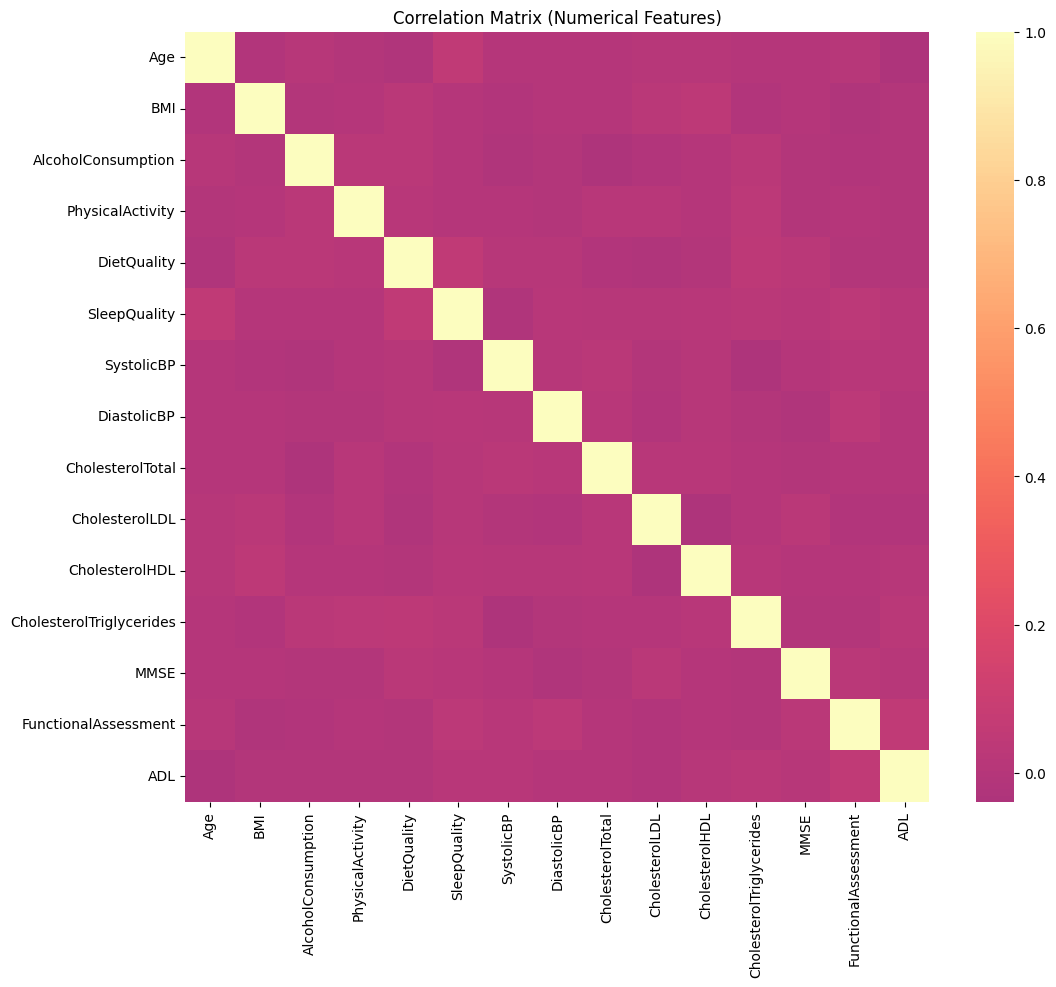

In [11]:
plt.figure(figsize=(12,10))
sns.heatmap(df[numeric_cols].corr(), cmap='magma', center=0)
plt.title("Correlation Matrix (Numerical Features)")
plt.show()

FEATURE VS TARGET

Age vs. Diagnosis

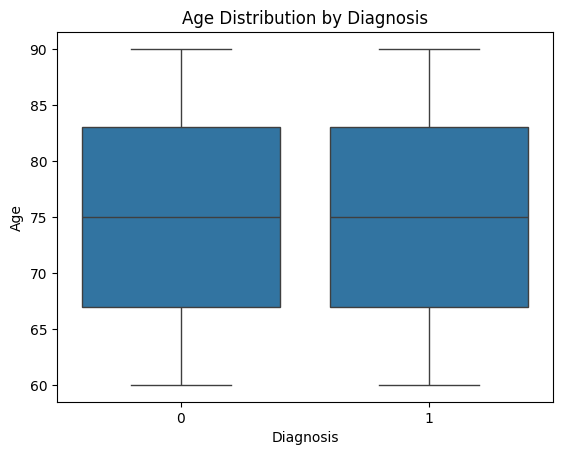

In [12]:
sns.boxplot(x='Diagnosis', y='Age', data=df)
plt.title("Age Distribution by Diagnosis")
plt.show()

MMSE vs Diagnosis

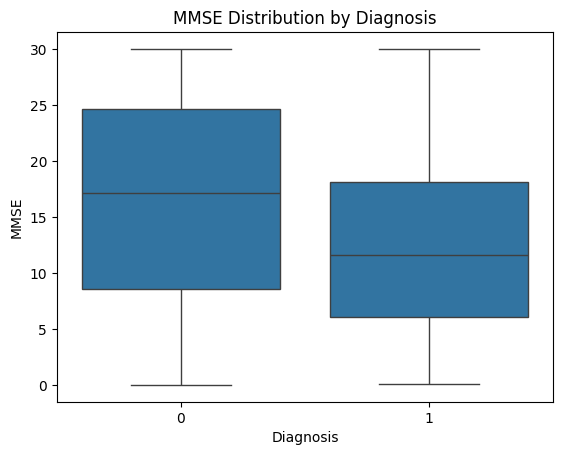

In [13]:
sns.boxplot(x='Diagnosis', y='MMSE', data=df)
plt.title("MMSE Distribution by Diagnosis")
plt.show()

Quick statistical comparison

In [14]:
df.groupby('Diagnosis')[numeric_cols].mean()

,Age,BMI,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,ADL
Diagnosis,,,,,,,,,,,,,,,
0,74.945284,27.515092,10.071880,4.90764,4.974839,7.124832,134.564435,89.778978,224.996342,125.361434,58.734832,226.571537,16.265543,5.860669,5.707951
1,74.842105,27.912670,9.980156,4.94316,5.026581,6.916292,133.717105,89.973684,225.565197,122.461726,60.795330,231.406671,11.994657,3.653380,3.657938


Prepare Data for Modeling

In [15]:
X = df.drop(columns=[target_col])
y = df[target_col]

# One-hot encode categorical variables
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Final feature shape:", X.shape)

Final feature shape: (2149, 36)


Train/Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1719, 36)
Test shape: (430, 36)


Scale Features

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Logistic Regression Baseline

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Results")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Logistic Regression Results
              precision    recall  f1-score   support

           0       0.90      0.79      0.84       278
           1       0.69      0.85      0.76       152

    accuracy                           0.81       430
   macro avg       0.80      0.82      0.80       430
weighted avg       0.83      0.81      0.81       430

ROC-AUC: 0.8833775085195001
Confusion Matrix:
 [[219  59]
 [ 23 129]]


Significance table

In [ ]:
import statsmodels.api as sm
import numpy as np

# 1. Prepare data (ensure constant is added)
X_train_sm = sm.add_constant(X_train_scaled)
feature_names = ['(Intercept)'] + list(X_train.columns)

# 2. Fit the model
model_sm = sm.Logit(y_train.values, X_train_sm)
result = model_sm.fit(disp=0)

# 3. Extract Global Model Fit Metrics
pseudo_r2 = result.prsquared
ll_ratio_p = result.llr_pvalue  # Likelihood Ratio Test p-value

print(f"--- Model Fit Statistics ---")
print(f"McFadden's Pseudo-R2: {pseudo_r2:.4f}")
print(f"LRT P-Value: {ll_ratio_p:.4e} (Model is significant if < 0.05)")
print("-" * 30)

# 4. Create the detailed Odds Ratio Table with 95% CI
params = result.params
conf = result.conf_int()
p_values = result.pvalues

# Build DataFrame
or_table = pd.DataFrame({
    'Coefficient (B)': params,
    'Std. Error': result.bse,
    'P-Value': p_values,
    'Odds Ratio (OR)': np.exp(params),
    '95% CI Lower': np.exp(conf[:, 0]),
    '95% CI Upper': np.exp(conf[:, 1])
})

# 5. Add Significance Stars for easier reading
def sig_stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'

or_table['Sig.'] = or_table['P-Value'].apply(sig_stars)
or_table.index = feature_names

# Reorder columns for the report
final_cols = ['Coefficient (B)', 'P-Value', 'Sig.', 'Odds Ratio (OR)', '95% CI Lower', '95% CI Upper']
display(or_table[final_cols].round(4))

--- Model Fit Statistics ---
McFadden's Pseudo-R2: 0.4501
LRT P-Value: 1.1892e-187 (Model is significant if < 0.05)
------------------------------


,Coefficient (B),P-Value,Sig.,Odds Ratio (OR),95% CI Lower,95% CI Upper
(Intercept),-1.1777,0.0000,***,0.3080,0.2617,0.3625
Age,-0.1464,0.0450,*,0.8638,0.7486,0.9967
Gender,-0.0037,0.9598,ns,0.9963,0.8639,1.1491
BMI,-0.0165,0.8205,ns,0.9836,0.8528,1.1345
Smoking,-0.0553,0.4499,ns,0.9462,0.8196,1.0922
AlcoholConsumption,-0.0418,0.5595,ns,0.9590,0.8333,1.1037
PhysicalActivity,-0.0364,0.6103,ns,0.9642,0.8382,1.1092
DietQuality,0.0003,0.9968,ns,1.0003,0.8657,1.1558
SleepQuality,-0.1074,0.1417,ns,0.8982,0.7783,1.0365
FamilyHistoryAlzheimers,-0.0640,0.3846,ns,0.9380,0.8120,1.0836


Forest Plot visual

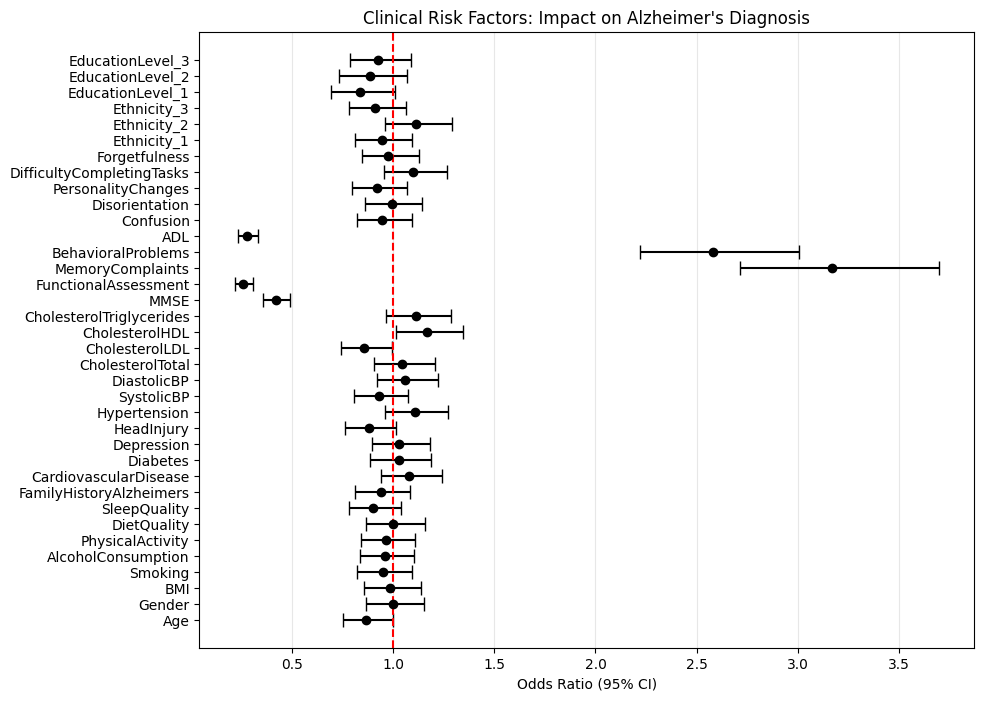

In [21]:
import matplotlib.pyplot as plt

# Exclude intercept for better scaling of the plot
plot_table = or_table.drop('(Intercept)')

plt.figure(figsize=(10, 8))
plt.errorbar(plot_table['Odds Ratio (OR)'], plot_table.index,
             xerr=[plot_table['Odds Ratio (OR)'] - plot_table['95% CI Lower'],
                   plot_table['95% CI Upper'] - plot_table['Odds Ratio (OR)']],
             fmt='o', color='black', capsize=5)

plt.axvline(x=1, color='red', linestyle='--') # Red line at OR=1 (No effect)
plt.xlabel('Odds Ratio (95% CI)')
plt.title('Clinical Risk Factors: Impact on Alzheimer\'s Diagnosis')
plt.grid(axis='x', alpha=0.3)
plt.show()

ROC Curve and confusion matrix

c:\Users\jonas\Projects\uib\381\Alzheimer-s-Analytics\venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


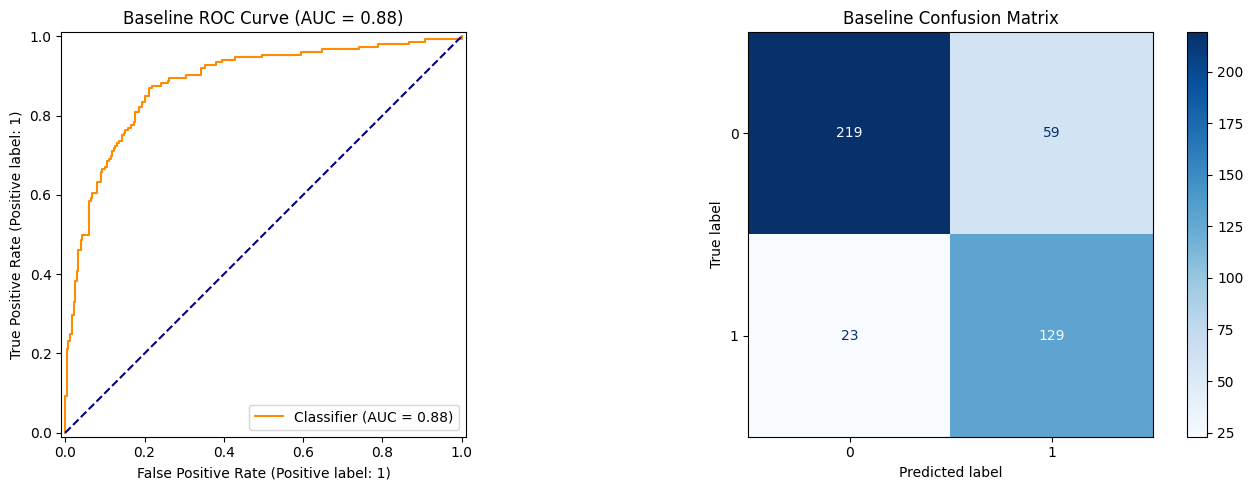

In [ ]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay, roc_curve, auc

# This "captures" the numbers
fpr_full, tpr_full, _ = roc_curve(y_test, y_prob_lr)
roc_auc_full = auc(fpr_full, tpr_full)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob_lr, ax=ax[0], color='darkorange')
ax[0].plot([0, 1], [0, 1], color='navy', linestyle='--')
ax[0].set_title(f'Baseline ROC Curve (AUC = {roc_auc_full:.2f})')

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, cmap='Blues', ax=ax[1])
ax[1].set_title('Baseline Confusion Matrix')

plt.tight_layout()
plt.show()

5-fold cross-validation

In [23]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Set up the cross-validation strategy
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Calculate ROC-AUC across 5 folds
cv_results = cross_val_score(log_reg, X_train_scaled, y_train,
                             cv=skf, scoring='roc_auc')

print(f"Baseline CV ROC-AUC Scores: {cv_results}")
print(f"Mean ROC-AUC: {cv_results.mean():.4f} (+/- {cv_results.std() * 2:.4f})")

Baseline CV ROC-AUC Scores: [0.91042508 0.88380594 0.90481465 0.92094964 0.8955774 ]
Mean ROC-AUC: 0.9031 (+/- 0.0254)


CV Performance Boxplot

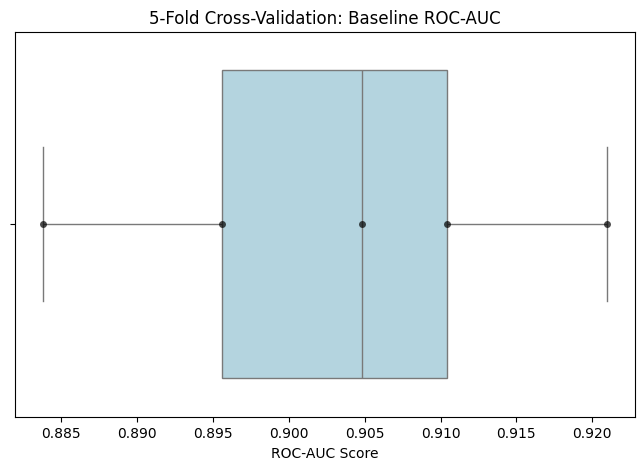

In [24]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=cv_results, color='lightblue')
sns.swarmplot(x=cv_results, color='black', alpha=0.7) # Shows the individual fold points
plt.title('5-Fold Cross-Validation: Baseline ROC-AUC')
plt.xlabel('ROC-AUC Score')
plt.show()

Combined Reduced-Feature Analysis


In [ ]:
import statsmodels.api as sm
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, accuracy_score, f1_score

# (The "Reduced" Experiment)
# We exclude direct cognitive markers to see if lifestyle/demographics alone work
exclude_cols = [
    'MMSE', 'ADL', 'FunctionalAssessment',
    'MemoryComplaints', 'BehavioralProblems',
    'Confusion', 'Disorientation', 'PersonalityChanges',
    'DifficultyCompletingTasks', 'Forgetfulness'
]

X_reduced = X.drop(columns=exclude_cols, errors='ignore')

# TRAIN/TEST SPLIT & SCALING
X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reduced, y, test_size=0.2, stratify=y, random_state=42
)

scaler_red = StandardScaler()
X_train_red_scaled = scaler_red.fit_transform(X_train_red)
X_test_red_scaled = scaler_red.transform(X_test_red)

# SKLEARN MODEL
log_reg_red = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg_red.fit(X_train_red_scaled, y_train_red)

y_prob_red = log_reg_red.predict_proba(X_test_red_scaled)[:, 1]
y_pred_red = log_reg_red.predict(X_test_red_scaled)
print(f"Reduced-Feature ROC-AUC: {roc_auc_score(y_test_red, y_prob_red):.4f}")

# STATSMODELS
X_train_red_sm = sm.add_constant(X_train_red_scaled)
y_train_numeric = y_train_red.astype(float)

model_red_sm = sm.Logit(y_train_numeric, X_train_red_sm)
res_red = model_red_sm.fit(disp=0)

# Extract Model Fit
print(f"Reduced Model McFadden's Pseudo-R2: {res_red.prsquared:.4f}")
print("-" * 30)

# Build the Detailed Table using .iloc for the Confidence Intervals
params_red = res_red.params
conf_red = res_red.conf_int() # This is a DataFrame
p_vals_red = res_red.pvalues
acc_red = accuracy_score(y_test_red, y_pred_red)
f1_red = f1_score(y_test_red, y_pred_red)
auc_red = roc_auc_score(y_test_red, y_prob_red)

red_summary_table = pd.DataFrame({
    'Coefficient (B)': params_red,
    'P-Value': p_vals_red,
    'Odds Ratio (OR)': np.exp(params_red),
    '95% CI Lower': np.exp(conf_red.iloc[:, 0]), # Use .iloc for the first column
    '95% CI Upper': np.exp(conf_red.iloc[:, 1])  # Use .iloc for the second column
})
print("--- REDUCED FEATURE RESULTS (Lifestyle Only) ---")
print(f"Accuracy: {acc_red:.4f}")
print(f"F1-Score: {f1_red:.4f}")
print("\nReduced Classification Report:")
print(classification_report(y_test_red, y_pred_red))

Reduced-Feature ROC-AUC: 0.5183
Reduced Model McFadden's Pseudo-R2: 0.0184
------------------------------
--- REDUCED FEATURE RESULTS (Lifestyle Only) ---
Accuracy: 0.4977
F1-Score: 0.4316

Reduced Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.47      0.55       278
           1       0.36      0.54      0.43       152

    accuracy                           0.50       430
   macro avg       0.51      0.51      0.49       430
weighted avg       0.55      0.50      0.51       430



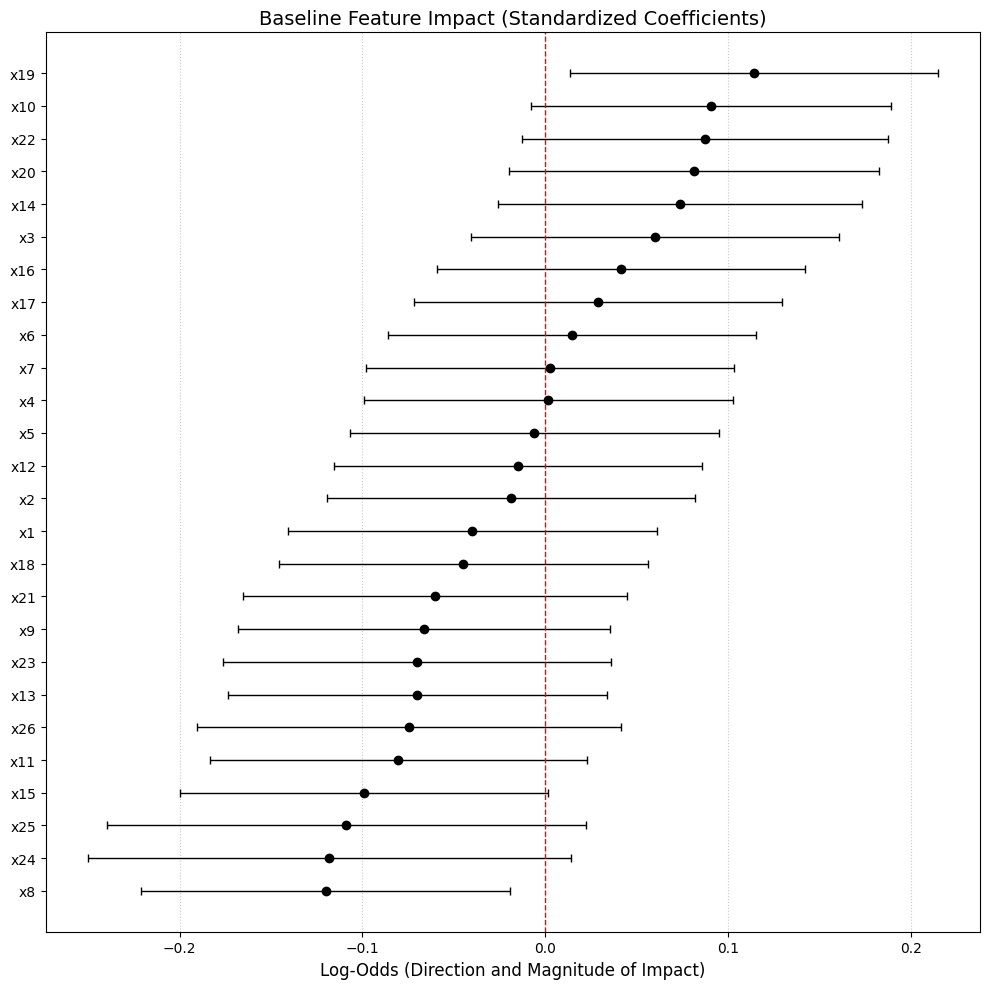

In [ ]:
# Use the table name from the previous cell
plot_df = red_summary_table.iloc[1:].copy().reset_index().rename(columns={'index': 'Feature'})

# Sort by Coefficient
plot_df = plot_df.sort_values('Coefficient (B)')

plt.figure(figsize=(10, 10))

# Use 1.96 * Standard Error for the 95% Confidence Interval
plt.errorbar(plot_df['Coefficient (B)'],
             plot_df['Feature'],
             xerr=[plot_df['Coefficient (B)'] - np.log(plot_df['95% CI Lower']),
                   np.log(plot_df['95% CI Upper']) - plot_df['Coefficient (B)']],
             fmt='o', color='black', capsize=3, elinewidth=1)

# 4. Vertical line at 0 (In Log-Odds, 0 means "No Effect")
plt.axvline(0, color='red', linestyle='--', linewidth=1)

plt.title('Baseline Feature Impact (Standardized Coefficients)', fontsize=14)
plt.xlabel('Log-Odds (Direction and Magnitude of Impact)', fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

Logistic Regression Coefficients. Shows which features increase or decrease Alzheimer risk according to logistic regression

ROC Curve and Confusion Matrix Reduced-Feature Experiment

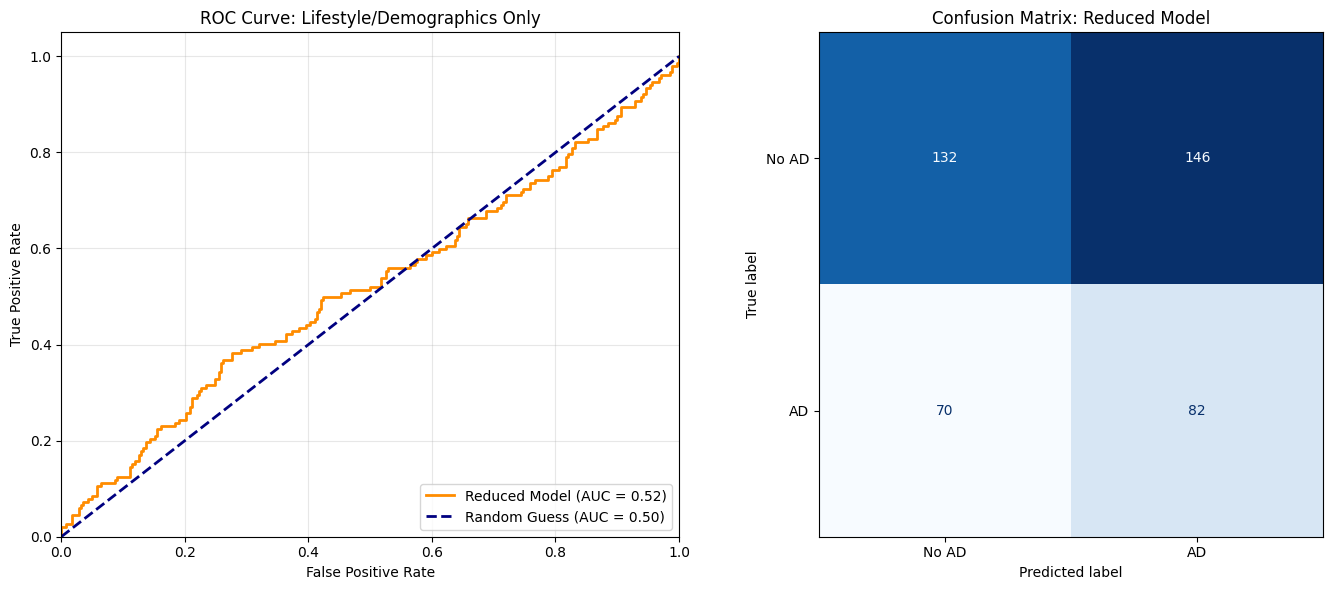

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# Calculate the ROC Curve data
fpr_red, tpr_red, _ = roc_curve(y_test_red, y_prob_red)
roc_auc_red = auc(fpr_red, tpr_red)

# Create a side-by-side plot
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
ax[0].plot(fpr_red, tpr_red, color='darkorange', lw=2, label=f'Reduced Model (AUC = {roc_auc_red:.2f})')
ax[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')
ax[0].set_xlim([0.0, 1.0])
ax[0].set_ylim([0.0, 1.05])
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('ROC Curve: Lifestyle/Demographics Only')
ax[0].legend(loc="lower right")
ax[0].grid(alpha=0.3)

# Confusion Matrix
# Use a threshold of 0.5 for binary classification
y_pred_red = (y_prob_red > 0.5).astype(int)
cm_red = confusion_matrix(y_test_red, y_pred_red)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_red, display_labels=['No AD', 'AD'])
disp.plot(ax=ax[1], cmap='Blues', colorbar=False)
ax[1].set_title('Confusion Matrix: Reduced Model')

plt.tight_layout()
plt.show()

"Interpretability" visualization

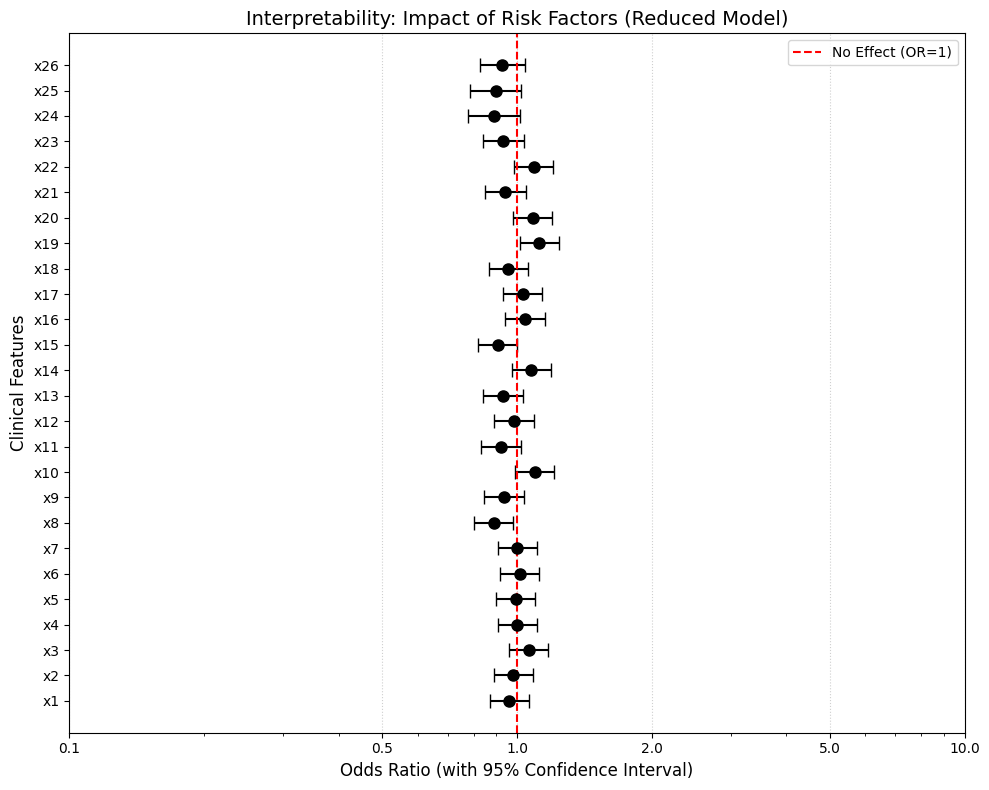

In [29]:
import matplotlib.pyplot as plt

# Use .iloc[1:] to skip the first row (the intercept)
plot_table = red_summary_table.iloc[1:]

plt.figure(figsize=(10, 8))

# Create the Forest Plot
plt.errorbar(plot_table['Odds Ratio (OR)'],
             plot_table.index,
             xerr=[plot_table['Odds Ratio (OR)'] - plot_table['95% CI Lower'],
                   plot_table['95% CI Upper'] - plot_table['Odds Ratio (OR)']],
             fmt='o', color='black', capsize=5, markersize=8)

# Add the "Line of No Effect" at OR = 1
plt.axvline(x=1, color='red', linestyle='--', linewidth=1.5, label='No Effect (OR=1)')

# Final Formatting
plt.xlabel('Odds Ratio (with 95% Confidence Interval)', fontsize=12)
plt.ylabel('Clinical Features', fontsize=12)
plt.title('Interpretability: Impact of Risk Factors (Reduced Model)', fontsize=14)
plt.grid(axis='x', linestyle=':', alpha=0.6)

# Use a log scale for the X-axis
plt.xscale('log')

# Clean up the X-axis ticks
from matplotlib.ticker import ScalarFormatter
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.xticks([0.1, 0.5, 1, 2, 5, 10])

plt.legend()
plt.tight_layout()

plt.show()

5-Fold Cross-Validation

In [30]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression CV
lr_cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
print("Logistic Regression 5-Fold ROC-AUC:", lr_cv_scores.mean(), "+/-", lr_cv_scores.std())


Logistic Regression 5-Fold ROC-AUC: 0.9031145408000782 +/- 0.012681134228160258


Feature Significance / p-values

In [31]:
import statsmodels.api as sm

# Convert to numeric arrays
y_train_numeric = pd.to_numeric(y_train, errors='coerce').values.astype(float)
X_train_sm = sm.add_constant(X_train.values.astype(float))

# Check for NaN values
print(f"NaN values in y_train: {np.isnan(y_train_numeric).sum()}")
print(f"NaN values in X_train: {np.isnan(X_train_sm).sum()}")
print(f"y_train unique values: {np.unique(y_train_numeric)}")

model_sm = sm.Logit(y_train_numeric, X_train_sm)
result = model_sm.fit(disp=0)
feature_names = ['const'] + list(X_train.columns)
print(result.summary(xname=feature_names))

NaN values in y_train: 0
NaN values in X_train: 0
y_train unique values: [0. 1.]
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 1719
Model:                          Logit   Df Residuals:                     1682
Method:                           MLE   Df Model:                           36
Date:                Fri, 10 Apr 2026   Pseudo R-squ.:                  0.4501
Time:                        12:02:00   Log-Likelihood:                -614.16
converged:                       True   LL-Null:                       -1116.8
Covariance Type:            nonrobust   LLR p-value:                1.189e-187
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         5.7433      1.124      5.111      0.000       3.541       7.946
Age  

Odd-ratio table

In [33]:
# Get coefficients and confidence intervals
params = result.params
conf = result.conf_int()

# Convert to DataFrame immediately to avoid the IndexError
or_table = pd.DataFrame(conf, columns=['Lower 95%', 'Upper 95%'])

# Add the other metrics
or_table['OR'] = params
or_table['p-value'] = result.pvalues

# Exponentiate the columns (except p-value) to get actual Odds Ratios
# We only exponentiate the first three columns
or_table[['Lower 95%', 'Upper 95%', 'OR']] = np.exp(or_table[['Lower 95%', 'Upper 95%', 'OR']])

# Map back the feature names
feature_names = ['const'] + list(X_train.columns)
or_table.index = feature_names

print("Odds Ratio Table")
display(or_table.round(4))

Odds Ratio Table


,Lower 95%,Upper 95%,OR,p-value
const,34.4939,2823.5703,312.0831,0.0000
Age,0.9684,0.9996,0.9839,0.0450
Gender,0.7463,1.3203,0.9927,0.9598
BMI,0.9782,1.0176,0.9977,0.8205
Smoking,0.6457,1.2141,0.8854,0.4499
AlcoholConsumption,0.9688,1.0173,0.9928,0.5595
PhysicalActivity,0.9400,1.0370,0.9873,0.6103
DietQuality,0.9517,1.0510,1.0001,0.9968
SleepQuality,0.8678,1.0205,0.9410,0.1417
FamilyHistoryAlzheimers,0.6186,1.2033,0.8628,0.3846


Unified Results Table

In [ ]:
import numpy as np

# Extract results
params = result.params
std_err = result.bse
p_values = result.pvalues
conf = result.conf_int()

# Build the DataFrame using the arrays directly
summary_table = pd.DataFrame(index=range(len(params)))

summary_table['Coefficient (B)'] = params
summary_table['Std. Error'] = std_err
summary_table['P-Value'] = p_values
summary_table['Odds Ratio (OR)'] = np.exp(params)

# Extract Lower and Upper CI bounds 
summary_table['95% CI Lower'] = np.exp(conf[:, 0])
summary_table['95% CI Upper'] = np.exp(conf[:, 1])

# Add Significance Stars
def get_stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return ''

summary_table['Sig.'] = summary_table['P-Value'].apply(get_stars)

# Map the Feature Names
feature_names = ['(Intercept)'] + list(X_train.columns)
summary_table.index = feature_names

# Final Formatting and Reordering
final_cols = ['Coefficient (B)', 'Std. Error', 'P-Value', 'Sig.', 'Odds Ratio (OR)', '95% CI Lower', '95% CI Upper']
summary_table = summary_table[final_cols]

print("Final Model Results Table")
display(summary_table.round(4))

Final Model Results Table


,Coefficient (B),Std. Error,P-Value,Sig.,Odds Ratio (OR),95% CI Lower,95% CI Upper
(Intercept),5.7433,1.1237,0.0000,***,312.0831,34.4939,2823.5703
Age,-0.0162,0.0081,0.0450,*,0.9839,0.9684,0.9996
Gender,-0.0073,0.1455,0.9598,,0.9927,0.7463,1.3203
BMI,-0.0023,0.0101,0.8205,,0.9977,0.9782,1.0176
Smoking,-0.1217,0.1611,0.4499,,0.8854,0.6457,1.2141
AlcoholConsumption,-0.0073,0.0124,0.5595,,0.9928,0.9688,1.0173
PhysicalActivity,-0.0128,0.0251,0.6103,,0.9873,0.9400,1.0370
DietQuality,0.0001,0.0253,0.9968,,1.0001,0.9517,1.0510
SleepQuality,-0.0608,0.0414,0.1417,,0.9410,0.8678,1.0205
FamilyHistoryAlzheimers,-0.1476,0.1697,0.3846,,0.8628,0.6186,1.2033


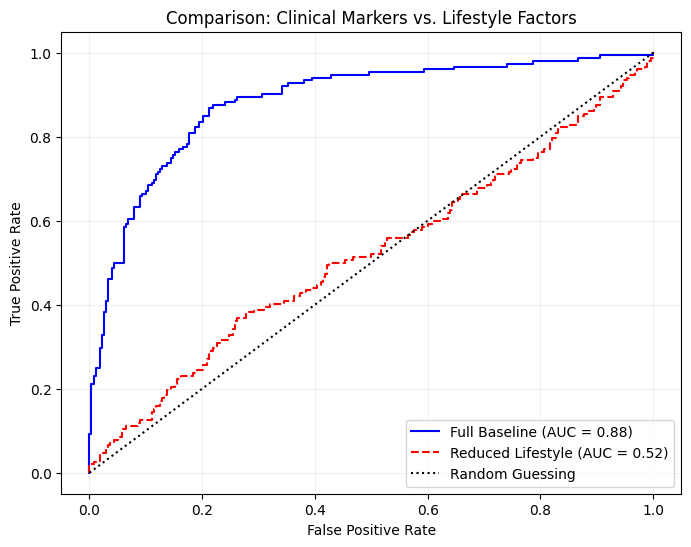

In [36]:
plt.figure(figsize=(8, 6))

# Plot Full Model 
plt.plot(fpr_full, tpr_full, color='blue', label=f'Full Baseline (AUC = {roc_auc_full:.2f})')

# Plot Reduced Model
plt.plot(fpr_red, tpr_red, color='red', linestyle='--', label=f'Reduced Lifestyle (AUC = {roc_auc_red:.2f})')

# Plot Random Line
plt.plot([0, 1], [0, 1], color='black', linestyle=':', label='Random Guessing')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparison: Clinical Markers vs. Lifestyle Factors')
plt.legend()
plt.grid(alpha=0.2)
plt.show()